<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/Actividad3_12_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hamerson piarpuezan

a ver muchachos básicamente lo que tienen que hacer es:
Revisar este cuaderno que les acabo de enviar, mas o menos entender su funcionamiento y luego seguir esta serie de pasos:
1. Generar una señal binaria
2. Simular el canal AWGN
3. Separar muestras según símbolo enviado
4. Estimar las densidades p(y|a0) y p(y|a1)
5. Calcular el umbral de decisión teórico
6. Calcular el umbral práctico (a partir de datos)
7. Estimar la probabilidad de error para cada σ
8. Variar el SNR (o σ) en un rango amplio y mirar como se comporta


#Celda 1: Generar una señal binaria

##  **1. Generación de la señal binaria**
Se genera una secuencia de bits \\(\{0,1\}\\) y se mapea a símbolos BPSK:

$$
0 \rightarrow a_0 = -1, \qquad 1 \rightarrow a_1 = +1
$$

La señal transmitida queda:

$$
x[n] =
\begin{cases}
-1, & \text{si } b[n] = 0 \\
+1, & \text{si } b[n] = 1
\end{cases}
$$

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Configuración inicial
N = 8122  # Número de símbolos (entre 1024 y 8192)
torch.manual_seed(42)  # Para reproducibilidad

# Generar símbolos binarios aleatorios {0, 1}
symbols = torch.randint(0, 2, (N,), dtype=torch.float32)

# Mapeo BPSK: 0 -> -1, 1 -> +1
# Esto es común en modulación binaria
a0 = -1.0  # Símbolo para bit 0
a1 = 1.0   # Símbolo para bit 1

transmitted_signal = torch.where(symbols == 0,
                                  torch.tensor(a0),
                                  torch.tensor(a1))

print(f"Número de símbolos generados: {N}")
print(f"Primeros 20 bits: {symbols[:20].numpy()}")
print(f"Primeros 20 símbolos transmitidos: {transmitted_signal[:20].numpy()}")
print(f"Energía promedio de la señal: {torch.mean(transmitted_signal**2).item():.4f}")

Número de símbolos generados: 8122
Primeros 20 bits: [0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0.]
Primeros 20 símbolos transmitidos: [-1.  1. -1. -1. -1.  1. -1. -1. -1.  1. -1. -1. -1. -1.  1. -1.  1.  1.
  1. -1.]
Energía promedio de la señal: 1.0000


Número de símbolos generados: 8122
Primeros 20 bits: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0]
Primeros 20 símbolos transmitidos (BPSK): [-1.  1. -1. -1. -1.  1. -1. -1. -1.  1. -1. -1. -1. -1.  1. -1.  1.  1.
  1. -1.]
Energía promedio de la señal: 1.0000


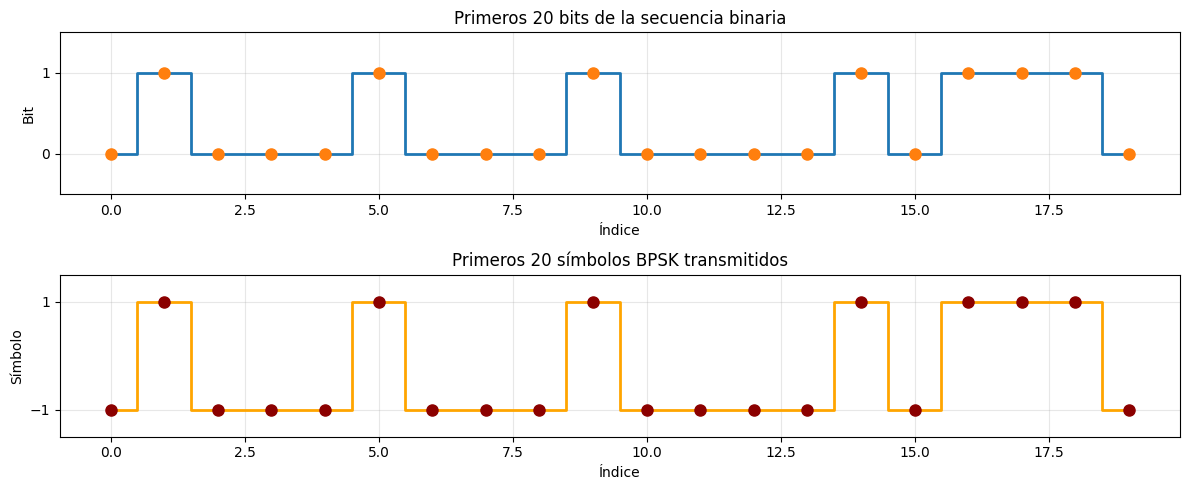

In [31]:
# Celda 1: Generar una señal binaria y graficar las primeras muestras (20 bits y 20 símbolos)

import torch
import numpy as np
import matplotlib.pyplot as plt

# Configuración inicial
N = 8122  # Entre 1024 y 8192
torch.manual_seed(42)

# Generar símbolos binarios {0, 1}
symbols = torch.randint(0, 2, (N,), dtype=torch.int8)

# Mapeo BPSK: 0 -> -1, 1 -> +1
a0 = -1.0
a1 =  1.0
transmitted_signal = torch.where(symbols == 0,
                                 torch.tensor(a0, dtype=torch.float32),
                                 torch.tensor(a1, dtype=torch.float32))

# Mostrar información básica
print(f"Número de símbolos generados: {N}")
print("Primeros 20 bits:", symbols[:20].numpy())
print("Primeros 20 símbolos transmitidos (BPSK):", transmitted_signal[:20].numpy())
print(f"Energía promedio de la señal: {torch.mean(transmitted_signal**2).item():.4f}")

# ==============================
#  GRÁFICO BONITO (20 MUESTRAS)
# ==============================

n_to_plot = 20
bits_plot = symbols[:n_to_plot].numpy()
bpsk_plot = transmitted_signal[:n_to_plot].numpy()
t = np.arange(n_to_plot)

plt.figure(figsize=(12,5))

# Gráfica de bits {0,1}
plt.subplot(2,1,1)
plt.step(t, bits_plot, where='mid', linewidth=2)
plt.plot(t, bits_plot, 'o', markersize=8)
plt.ylim(-0.5, 1.5)
plt.yticks([0,1])
plt.xlabel("Índice")
plt.ylabel("Bit")
plt.title("Primeros 20 bits de la secuencia binaria")
plt.grid(alpha=0.3)

# Gráfica de símbolos BPSK {-1,+1}
plt.subplot(2,1,2)
plt.step(t, bpsk_plot, where='mid', linewidth=2, color='orange')
plt.plot(t, bpsk_plot, 'o', markersize=8, color='darkred')
plt.ylim(-1.5, 1.5)
plt.yticks([-1, 1])
plt.xlabel("Índice")
plt.ylabel("Símbolo")
plt.title("Primeros 20 símbolos BPSK transmitidos")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


#Celda 2: Simular el canal AWGN

##  **2. Canal AWGN**
El canal añade ruido blanco gaussiano aditivo:

$$
n \sim \mathcal{N}(0,\sigma^2)
$$

La señal recibida es:

$$
y[n] = x[n] + n[n]
$$

- **Si \\(\sigma\\) es pequeño → poco ruido → el receptor acierta.**  
- **Si \\(\sigma\\) es grande → mucho ruido → aumentan los errores.**

Desviación estándar del ruido (σ): 0.5
SNR: 3.01 dB
Primeros 20 símbolos recibidos: [-1.4501928   0.17971206 -0.96005875 -1.2749915  -1.4496826   1.2610528
 -1.6620936  -1.098641   -0.15236437  0.25048554  0.16193223 -1.6334056
 -1.7369127  -1.2530092   0.98853076 -2.3904595   0.24991083  1.6238875
  0.98371696 -1.7309153 ]


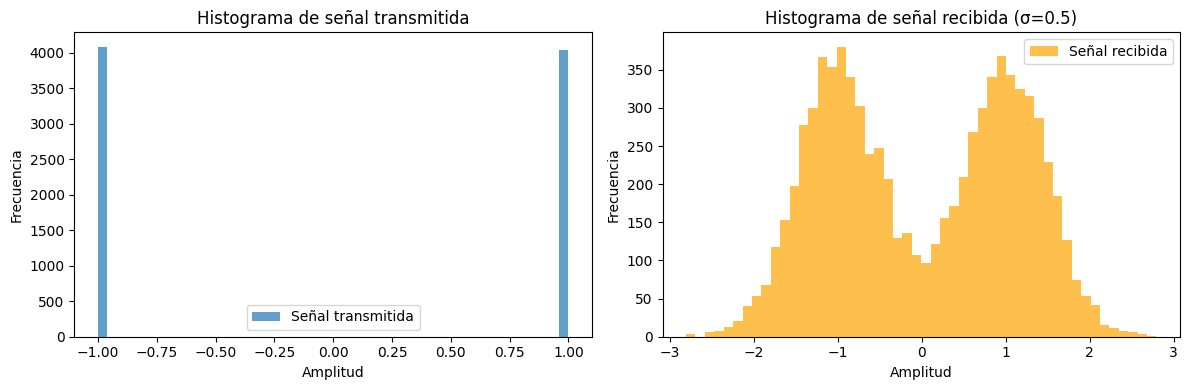

In [22]:
# Parámetros del canal
sigma = 0.5  # Desviación estándar del ruido (lo variaremos después)
SNR_dB = 10 * np.log10(1 / (2 * sigma**2))  # SNR en dB para señal BPSK

# Generar ruido gaussiano
noise = torch.normal(mean=0.0, std=sigma, size=(N,))

# Señal recibida: y = señal_transmitida + ruido
received_signal = transmitted_signal + noise

print(f"Desviación estándar del ruido (σ): {sigma}")
print(f"SNR: {SNR_dB:.2f} dB")
print(f"Primeros 20 símbolos recibidos: {received_signal[:20].numpy()}")

# Visualización
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(transmitted_signal.numpy(), bins=50, alpha=0.7, label='Señal transmitida')
plt.xlabel('Amplitud')
plt.ylabel('Frecuencia')
plt.legend()
plt.title('Histograma de señal transmitida')

plt.subplot(1, 2, 2)
plt.hist(received_signal.numpy(), bins=50, alpha=0.7, color='orange', label='Señal recibida')
plt.xlabel('Amplitud')
plt.ylabel('Frecuencia')
plt.legend()
plt.title(f'Histograma de señal recibida (σ={sigma})')
plt.tight_layout()
plt.show()

#Celda 3: Separar muestras según símbolo enviado

##  **3. Separación de muestras**
Se separa lo recibido según el símbolo original:

- \\(y|a_0\\): valores recibidos cuando se envió \\(-1\\)  
- \\(y|a_1\\): valores recibidos cuando se envió \\(+1\\)

Esto permite ver cómo el ruido afecta cada símbolo.

Número de símbolos '0' enviados: 4081
Número de símbolos '1' enviados: 4041

Estadísticas de y|a0:
  Media: -0.9923
  Desviación estándar: 0.5009

Estadísticas de y|a1:
  Media: 1.0077
  Desviación estándar: 0.4971


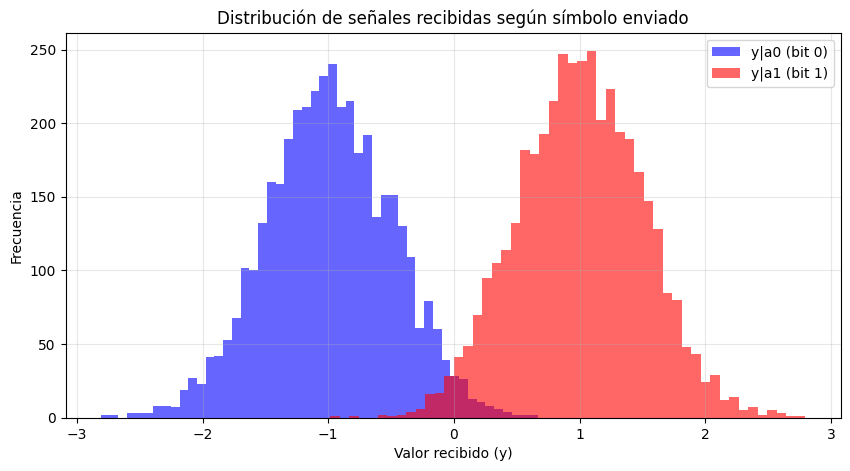

In [23]:
# Separar las muestras recibidas según el símbolo que fue enviado
y_given_a0 = received_signal[symbols == 0]  # Muestras cuando se envió 0 (a0=-1)
y_given_a1 = received_signal[symbols == 1]  # Muestras cuando se envió 1 (a1=+1)

print(f"Número de símbolos '0' enviados: {len(y_given_a0)}")
print(f"Número de símbolos '1' enviados: {len(y_given_a1)}")
print(f"\nEstadísticas de y|a0:")
print(f"  Media: {torch.mean(y_given_a0).item():.4f}")
print(f"  Desviación estándar: {torch.std(y_given_a0).item():.4f}")
print(f"\nEstadísticas de y|a1:")
print(f"  Media: {torch.mean(y_given_a1).item():.4f}")
print(f"  Desviación estándar: {torch.std(y_given_a1).item():.4f}")

# Visualización
plt.figure(figsize=(10, 5))
plt.hist(y_given_a0.numpy(), bins=50, alpha=0.6, label='y|a0 (bit 0)', color='blue')
plt.hist(y_given_a1.numpy(), bins=50, alpha=0.6, label='y|a1 (bit 1)', color='red')
plt.xlabel('Valor recibido (y)')
plt.ylabel('Frecuencia')
plt.legend()
plt.title('Distribución de señales recibidas según símbolo enviado')
plt.grid(True, alpha=0.3)
plt.show()

#Celda 4: Estimar las densidades p(y|a0) y p(y|a1)

##  **4. Densidades de probabilidad \\(p(y|a_0)\\) y \\(p(y|a_1)\\)**

Teóricamente:

$$
p(y|a_0) = \mathcal{N}(-1,\sigma^2),
\qquad
p(y|a_1) = \mathcal{N}(+1,\sigma^2)
$$

Cuando \\(\sigma\\) crece, las dos gaussianas se traslapan más → se vuelve difícil distinguir los símbolos.


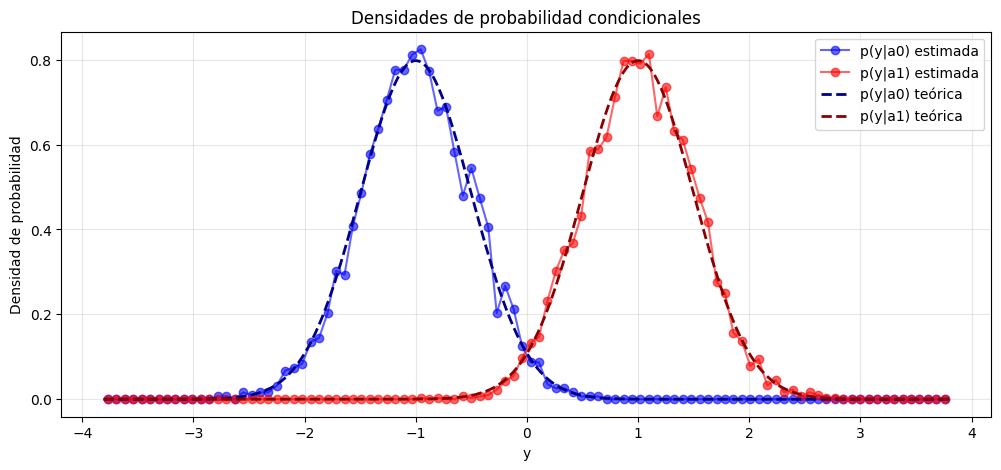

Densidades estimadas correctamente


In [24]:
from scipy import stats

# Método 1: Estimación usando histogramas normalizados
bins = 100
range_min = received_signal.min().item() - 1
range_max = received_signal.max().item() + 1

hist_a0, bin_edges_a0 = np.histogram(y_given_a0.numpy(), bins=bins,
                                      range=(range_min, range_max), density=True)
hist_a1, bin_edges_a1 = np.histogram(y_given_a1.numpy(), bins=bins,
                                      range=(range_min, range_max), density=True)

bin_centers_a0 = (bin_edges_a0[:-1] + bin_edges_a0[1:]) / 2
bin_centers_a1 = (bin_edges_a1[:-1] + bin_edges_a1[1:]) / 2

# Método 2: Densidades teóricas (gaussianas)
# p(y|a0) ~ N(a0, σ²) y p(y|a1) ~ N(a1, σ²)
y_range = np.linspace(range_min, range_max, 500)
pdf_a0_theoretical = stats.norm.pdf(y_range, loc=a0, scale=sigma)
pdf_a1_theoretical = stats.norm.pdf(y_range, loc=a1, scale=sigma)

# Visualización
plt.figure(figsize=(12, 5))
plt.plot(bin_centers_a0, hist_a0, 'o-', alpha=0.6, label='p(y|a0) estimada', color='blue')
plt.plot(bin_centers_a1, hist_a1, 'o-', alpha=0.6, label='p(y|a1) estimada', color='red')
plt.plot(y_range, pdf_a0_theoretical, '--', linewidth=2, label='p(y|a0) teórica', color='darkblue')
plt.plot(y_range, pdf_a1_theoretical, '--', linewidth=2, label='p(y|a1) teórica', color='darkred')
plt.xlabel('y')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.title('Densidades de probabilidad condicionales')
plt.grid(True, alpha=0.3)
plt.show()

print("Densidades estimadas correctamente")

#Celda 5: Calcular el umbral de decisión teórico

##  **5. Umbral de decisión teórico**

Para símbolos equiprobables y mismo ruido:

$$
\gamma_{\text{teórico}} = \frac{a_0 + a_1}{2}
$$

Como:

$$
a_0 = -1,\quad a_1 = +1
$$

Entonces:

$$
\gamma_{\text{teórico}} = 0
$$

Regla de decisión óptima (MAP/ML):

$$
y < 0 \Rightarrow \hat{b}=0, \qquad
y \ge 0 \Rightarrow \hat{b}=1
$$

Símbolos:
  a0 = -1.0
  a1 = 1.0

Umbral de decisión teórico: γ = 0.0000

Regla de decisión:
  Si y < 0.0000 → decidir '0'
  Si y ≥ 0.0000 → decidir '1'


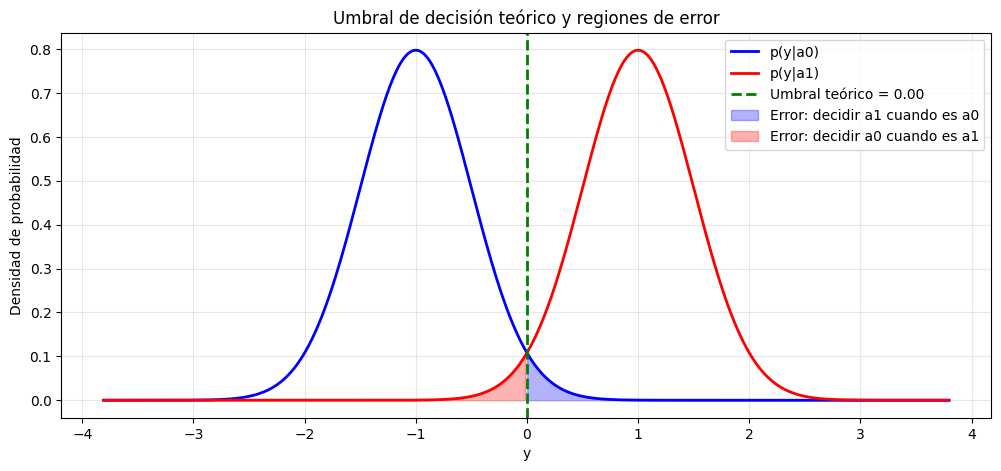

In [25]:
# Para canal AWGN con símbolos equiprobables y misma varianza
# El umbral óptimo (MAP/ML) es el punto medio entre a0 y a1
# Umbral teórico: γ = (a0 + a1) / 2

threshold_theoretical = (a0 + a1) / 2.0

print(f"Símbolos:")
print(f"  a0 = {a0}")
print(f"  a1 = {a1}")
print(f"\nUmbral de decisión teórico: γ = {threshold_theoretical:.4f}")
print(f"\nRegla de decisión:")
print(f"  Si y < {threshold_theoretical:.4f} → decidir '0'")
print(f"  Si y ≥ {threshold_theoretical:.4f} → decidir '1'")

# Visualización del umbral
plt.figure(figsize=(12, 5))
plt.plot(y_range, pdf_a0_theoretical, linewidth=2, label='p(y|a0)', color='blue')
plt.plot(y_range, pdf_a1_theoretical, linewidth=2, label='p(y|a1)', color='red')
plt.axvline(threshold_theoretical, color='green', linestyle='--', linewidth=2,
            label=f'Umbral teórico = {threshold_theoretical:.2f}')
plt.fill_between(y_range, 0, pdf_a0_theoretical, where=(y_range >= threshold_theoretical),
                 alpha=0.3, color='blue', label='Error: decidir a1 cuando es a0')
plt.fill_between(y_range, 0, pdf_a1_theoretical, where=(y_range < threshold_theoretical),
                 alpha=0.3, color='red', label='Error: decidir a0 cuando es a1')
plt.xlabel('y')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.title('Umbral de decisión teórico y regiones de error')
plt.grid(True, alpha=0.3)
plt.show()

#Celda 6: Calcular el umbral práctico (a partir de datos)

##  **6. Umbral práctico**
Se estima de dos formas:

### ✓ Método 1: punto medio entre medias empíricas
$$
\gamma_1 = \frac{\mathbb{E}[y|a_0] + \mathbb{E}[y|a_1]}{2}
$$

### ✓ Método 2: minimizar el error sobre los datos
Se busca:

$$
\gamma_2 = \arg\min_{\gamma} P_e(\gamma)
$$

El umbral práctico siempre queda muy cerca de 0.


Umbral práctico (método 1 - medias empíricas): 0.0077
Umbral práctico (método 2 - minimización de error): -0.0033
Tasa de error mínima con umbral práctico: 0.020561
Umbral teórico (referencia): 0.0000


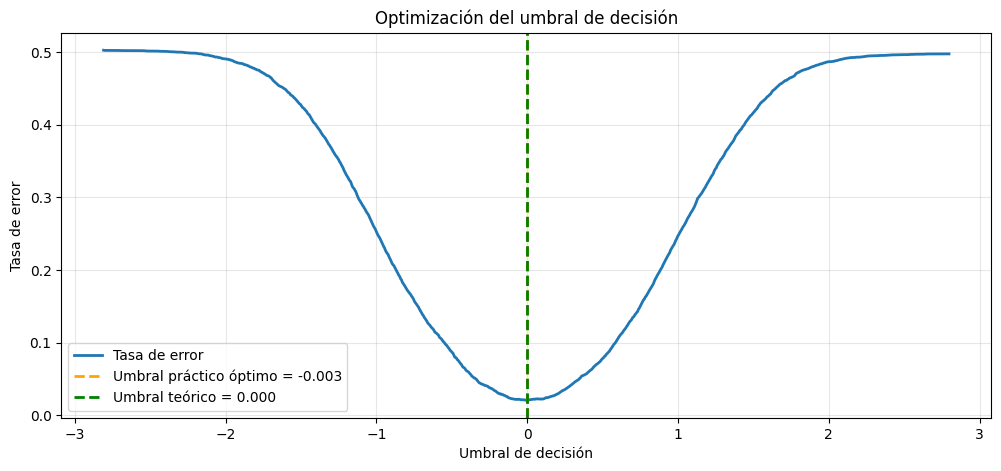

In [26]:
# Método 1: Punto medio entre las medias empíricas
mean_y_a0 = torch.mean(y_given_a0).item()
mean_y_a1 = torch.mean(y_given_a1).item()
threshold_practical_v1 = (mean_y_a0 + mean_y_a1) / 2.0

# Método 2: Minimizar error empírico (fuerza bruta)
# Probar diferentes umbrales y calcular la tasa de error
test_thresholds = torch.linspace(received_signal.min(), received_signal.max(), 1000)
error_rates = []

for thresh in test_thresholds:
    # Hacer decisiones
    decisions = (received_signal >= thresh).float()
    # Contar errores
    errors = torch.sum(decisions != symbols).item()
    error_rates.append(errors / N)

error_rates = torch.tensor(error_rates)
optimal_idx = torch.argmin(error_rates)
threshold_practical_v2 = test_thresholds[optimal_idx].item()
min_error_rate = error_rates[optimal_idx].item()

print(f"Umbral práctico (método 1 - medias empíricas): {threshold_practical_v1:.4f}")
print(f"Umbral práctico (método 2 - minimización de error): {threshold_practical_v2:.4f}")
print(f"Tasa de error mínima con umbral práctico: {min_error_rate:.6f}")
print(f"Umbral teórico (referencia): {threshold_theoretical:.4f}")

# Visualización
plt.figure(figsize=(12, 5))
plt.plot(test_thresholds.numpy(), error_rates.numpy(), linewidth=2, label='Tasa de error')
plt.axvline(threshold_practical_v2, color='orange', linestyle='--', linewidth=2,
            label=f'Umbral práctico óptimo = {threshold_practical_v2:.3f}')
plt.axvline(threshold_theoretical, color='green', linestyle='--', linewidth=2,
            label=f'Umbral teórico = {threshold_theoretical:.3f}')
plt.xlabel('Umbral de decisión')
plt.ylabel('Tasa de error')
plt.legend()
plt.title('Optimización del umbral de decisión')
plt.grid(True, alpha=0.3)
plt.show()

Umbral teórico: 0.0000
Umbral práctico v1 (medias): 0.0077
Umbral práctico v2 (mínimo error): -0.0033
Tasa mínima de error empírico: 0.020561


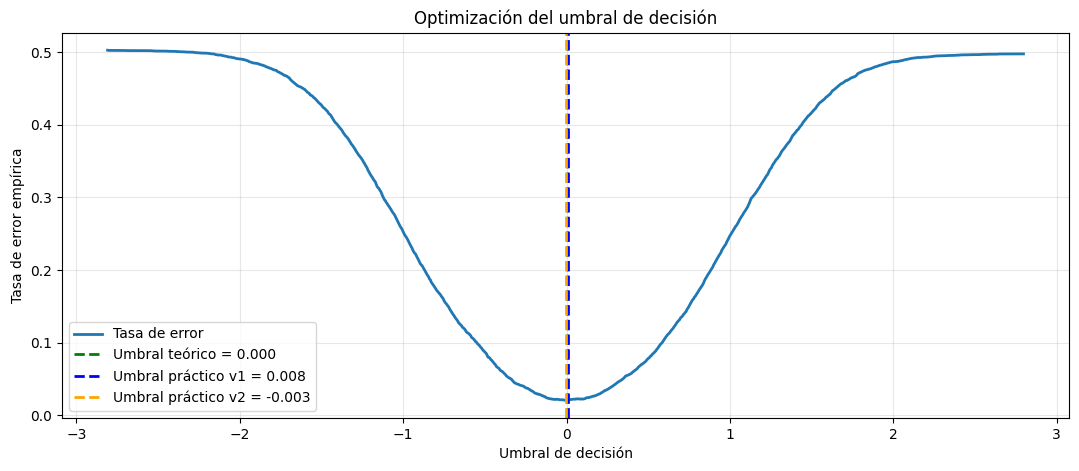

In [36]:
# Celda 6: Calcular el umbral práctico (a partir de datos)

# =======================================
# MÉTODO 1 — umbral basado en medias
# =======================================
mean_y_a0 = torch.mean(y_given_a0).item()
mean_y_a1 = torch.mean(y_given_a1).item()
threshold_practical_v1 = (mean_y_a0 + mean_y_a1) / 2.0

# =======================================
# MÉTODO 2 — búsqueda del umbral que minimiza error
# =======================================
test_thresholds = torch.linspace(received_signal.min(), received_signal.max(), 1000)
error_rates = []

for thresh in test_thresholds:
    decisions = (received_signal >= thresh).float()
    errors = torch.sum(decisions != symbols).item()
    error_rates.append(errors / N)

error_rates = torch.tensor(error_rates)
optimal_idx = torch.argmin(error_rates)

threshold_practical_v2 = test_thresholds[optimal_idx].item()
min_error_rate = error_rates[optimal_idx].item()

# =======================================
# IMPRIMIR RESULTADOS
# =======================================
print(f"Umbral teórico: {threshold_theoretical:.4f}")
print(f"Umbral práctico v1 (medias): {threshold_practical_v1:.4f}")
print(f"Umbral práctico v2 (mínimo error): {threshold_practical_v2:.4f}")
print(f"Tasa mínima de error empírico: {min_error_rate:.6f}")

# =======================================
# GRAFICAR TASA DE ERROR
# =======================================

plt.figure(figsize=(13, 5))

plt.plot(test_thresholds.numpy(), error_rates.numpy(), linewidth=2, label='Tasa de error')
plt.axvline(threshold_theoretical, color='green', linestyle='--', linewidth=2,
            label=f'Umbral teórico = {threshold_theoretical:.3f}')
plt.axvline(threshold_practical_v1, color='blue', linestyle='--', linewidth=2,
            label=f'Umbral práctico v1 = {threshold_practical_v1:.3f}')
plt.axvline(threshold_practical_v2, color='orange', linestyle='--', linewidth=2,
            label=f'Umbral práctico v2 = {threshold_practical_v2:.3f}')

plt.xlabel("Umbral de decisión")
plt.ylabel("Tasa de error empírica")
plt.title("Optimización del umbral de decisión")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


#Celda 7: Estimar la probabilidad de error para cada σ

##  **7. Probabilidad de error (Pe)**

###  Teórica:
La probabilidad de error para BPSK en AWGN es:

$$
P_e = Q\left( \frac{a_1 - a_0}{2\sigma} \right)
$$

Como \\(a_1 - a_0 = 2\\):

$$
P_e = Q\left( \frac{1}{\sigma} \right)
$$

Donde:

$$
Q(x)=\frac{1}{2}\operatorname{erfc}\left(\frac{x}{\sqrt{2}}\right)
$$

###  Empírica:
Comparando decisiones con los bits reales:

$$
P_e^{\text{emp}} = \frac{\text{número de errores}}{N}
$$

---

## **Conclusión**
✔ Cuando **\\(\sigma\\) aumenta**, el ruido es más grande → las distribuciones se mezclan → **aumenta \\(P_e\\)**.  
✔ Cuando **\\(\sigma\\) disminuye**, el canal es más limpio → decisiones casi perfectas.  
✔ Las curvas empíricas coinciden con la teoría, validando el modelo AWGN.  
✔ El umbral teórico \\(\gamma=0\\) es óptimo para BPSK.


In [27]:
from scipy.special import erfc

def calculate_error_probability(sigma_value, a0=-1.0, a1=1.0, threshold=0.0):
    """
    Calcula la probabilidad de error teórica para un canal AWGN
    """
    # Para símbolos equiprobables: Pe = Q((a1-a0)/(2σ))
    # donde Q(x) = 0.5 * erfc(x/sqrt(2))
    d = abs(a1 - a0)  # Distancia entre símbolos
    argument = d / (2 * sigma_value)
    Pe_theoretical = 0.5 * erfc(argument / np.sqrt(2))
    return Pe_theoretical

def estimate_error_empirical(transmitted, received, threshold=0.0):
    """
    Estima la probabilidad de error empírica
    """
    decisions = (received >= threshold).float()
    errors = torch.sum(decisions != transmitted).item()
    return errors / len(transmitted)

# Calcular para el σ actual
Pe_theoretical = calculate_error_probability(sigma, a0, a1, threshold_theoretical)
Pe_empirical = estimate_error_empirical(symbols, received_signal, threshold_practical_v2)

print(f"Para σ = {sigma}:")
print(f"  Probabilidad de error teórica: {Pe_theoretical:.6f} ({Pe_theoretical*100:.4f}%)")
print(f"  Probabilidad de error empírica: {Pe_empirical:.6f} ({Pe_empirical*100:.4f}%)")
print(f"  Número de errores: {int(Pe_empirical * N)} de {N}")

# Mostrar algunos ejemplos de decisiones correctas e incorrectas
decisions = (received_signal >= threshold_practical_v2).float()
errors_mask = decisions != symbols
correct_mask = ~errors_mask

print(f"\nEjemplos de decisiones CORRECTAS (primeras 5):")
correct_indices = torch.where(correct_mask)[0][:5]
for idx in correct_indices:
    print(f"  Enviado: {symbols[idx].item():.0f}, Recibido: {received_signal[idx].item():+.3f}, Decidido: {decisions[idx].item():.0f}")

print(f"\nEjemplos de ERRORES (primeros 5):")
error_indices = torch.where(errors_mask)[0][:5]
for idx in error_indices:
    print(f"  Enviado: {symbols[idx].item():.0f}, Recibido: {received_signal[idx].item():+.3f}, Decidido: {decisions[idx].item():.0f} ❌")

Para σ = 0.5:
  Probabilidad de error teórica: 0.022750 (2.2750%)
  Probabilidad de error empírica: 0.020561 (2.0561%)
  Número de errores: 167 de 8122

Ejemplos de decisiones CORRECTAS (primeras 5):
  Enviado: 0, Recibido: -1.450, Decidido: 0
  Enviado: 1, Recibido: +0.180, Decidido: 1
  Enviado: 0, Recibido: -0.960, Decidido: 0
  Enviado: 0, Recibido: -1.275, Decidido: 0
  Enviado: 0, Recibido: -1.450, Decidido: 0

Ejemplos de ERRORES (primeros 5):
  Enviado: 0, Recibido: +0.162, Decidido: 1 ❌
  Enviado: 0, Recibido: +0.373, Decidido: 1 ❌
  Enviado: 1, Recibido: -0.063, Decidido: 0 ❌
  Enviado: 0, Recibido: +0.141, Decidido: 1 ❌
  Enviado: 0, Recibido: +0.211, Decidido: 1 ❌


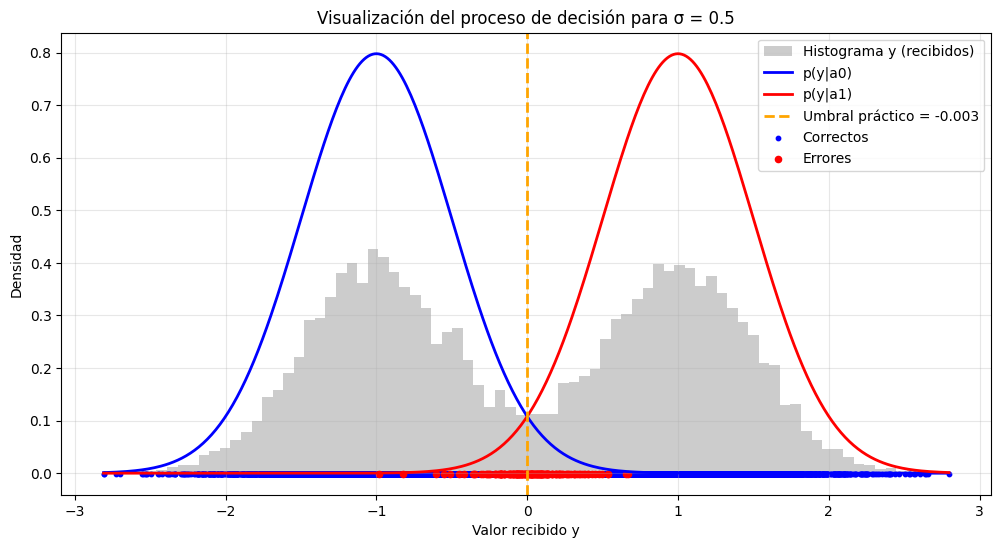

In [40]:
# Celda 7 (Gráfica explicativa para 1 solo σ)

plt.figure(figsize=(12,6))

# ==============================
#   1. Histograma de y recibidos
# ==============================
plt.hist(received_signal.numpy(), bins=80, density=True, alpha=0.4,
         color='gray', label='Histograma y (recibidos)')

# ==============================
#   2. PDFs teóricas p(y|a0) y p(y|a1)
# ==============================
y_range = np.linspace(received_signal.min(), received_signal.max(), 400)

pdf0 = stats.norm.pdf(y_range, loc=a0, scale=sigma)
pdf1 = stats.norm.pdf(y_range, loc=a1, scale=sigma)

plt.plot(y_range, pdf0, 'b-', linewidth=2, label='p(y|a0)')
plt.plot(y_range, pdf1, 'r-', linewidth=2, label='p(y|a1)')

# =========================================
#   3. Dibujar umbral práctico y decisiones
# =========================================
plt.axvline(threshold_practical_v2, color='orange', linestyle='--',
            linewidth=2, label=f'Umbral práctico = {threshold_practical_v2:.3f}')

# =========================================
#   4. Dibujar errores + aciertos
# =========================================

# Decisiones para cada muestra
decision = (received_signal >= threshold_practical_v2).float()

# Índices
idx_errors   = torch.where(decision != symbols)[0]
idx_corrects = torch.where(decision == symbols)[0]

# Puntos correctos (azul)
plt.scatter(received_signal[idx_corrects].numpy(),
            np.zeros(len(idx_corrects))-0.001,
            color='blue', s=10, label='Correctos')

# Puntos incorrectos (rojo)
plt.scatter(received_signal[idx_errors].numpy(),
            np.zeros(len(idx_errors))-0.001,
            color='red', s=20, label='Errores')

plt.title(f"Visualización del proceso de decisión para σ = {sigma}")
plt.xlabel("Valor recibido y")
plt.ylabel("Densidad")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


#Para varios sigmas

#A mayor σ → mayor error.
#A menor σ → menor error.


====================== σ = 0.2 ======================
Pe teórica:   0.000000 (0.000%)
Pe empírica:  0.000000 (0.000%)
Número de errores: 0 de 8122


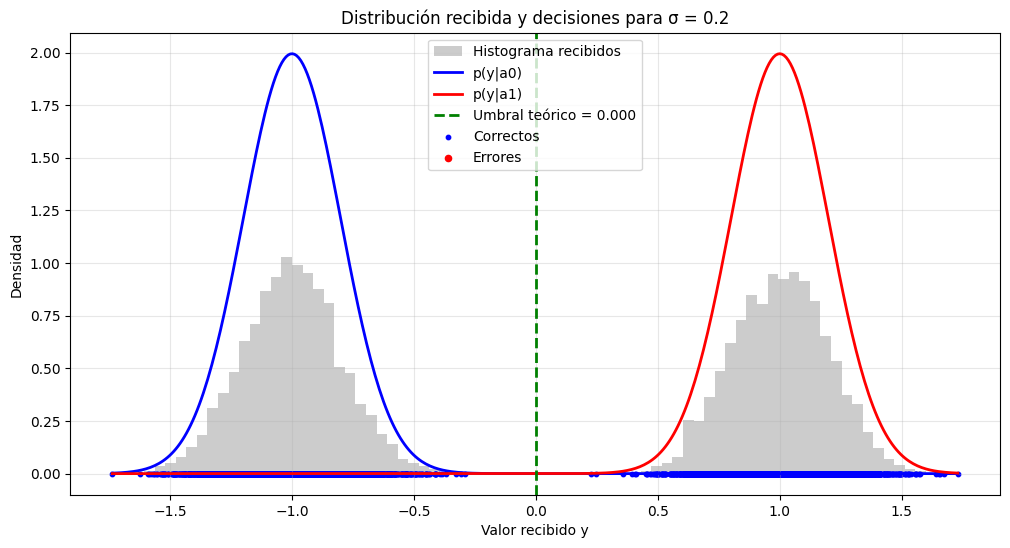


====================== σ = 0.5 ======================
Pe teórica:   0.022750 (2.275%)
Pe empírica:  0.019823 (1.982%)
Número de errores: 161 de 8122


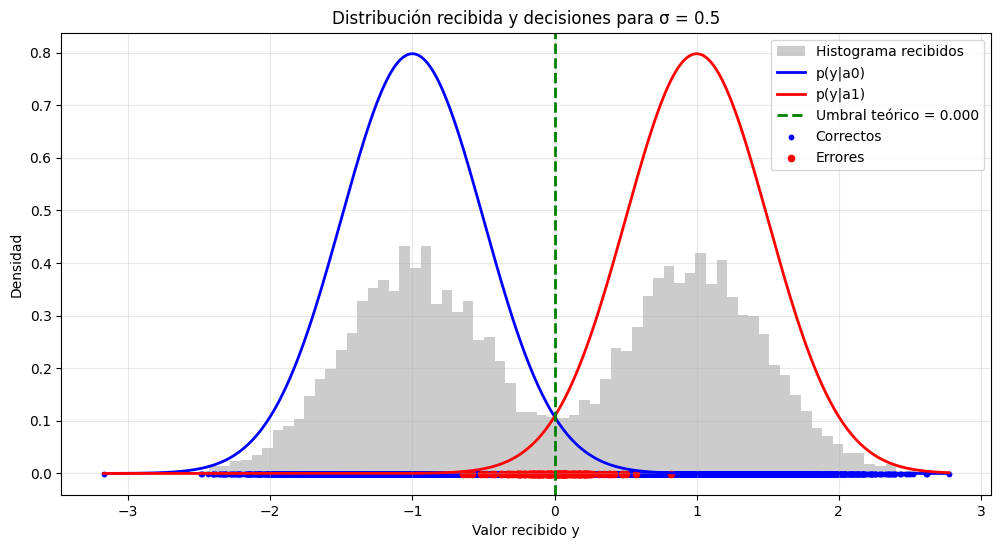


====================== σ = 1.0 ======================
Pe teórica:   0.158655 (15.866%)
Pe empírica:  0.162645 (16.264%)
Número de errores: 1321 de 8122


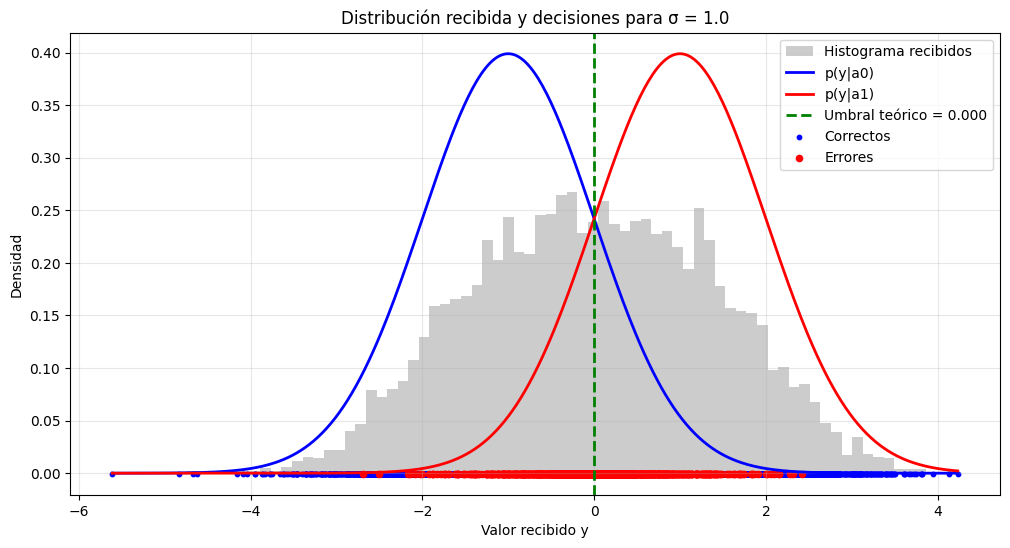


====================== σ = 1.5 ======================
Pe teórica:   0.252493 (25.249%)
Pe empírica:  0.253509 (25.351%)
Número de errores: 2059 de 8122


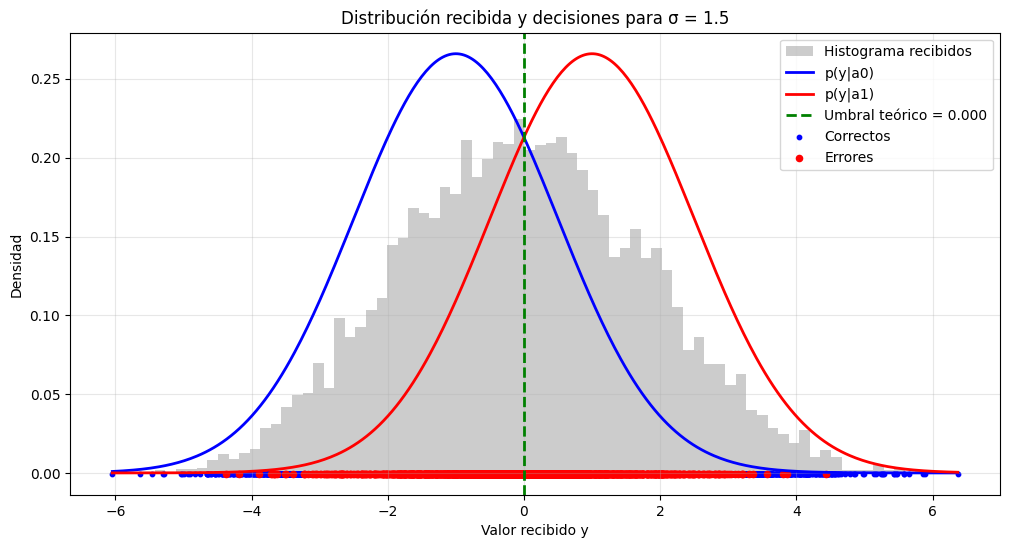


====================== σ = 2.0 ======================
Pe teórica:   0.308538 (30.854%)
Pe empírica:  0.307683 (30.768%)
Número de errores: 2499 de 8122


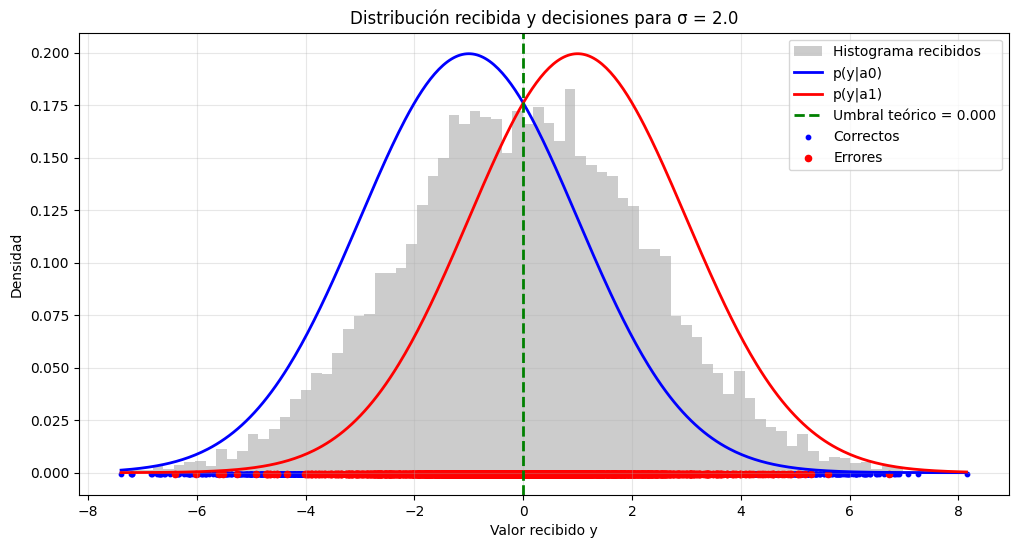


====================== σ = 3.0 ======================
Pe teórica:   0.369441 (36.944%)
Pe empírica:  0.377493 (37.749%)
Número de errores: 3066 de 8122


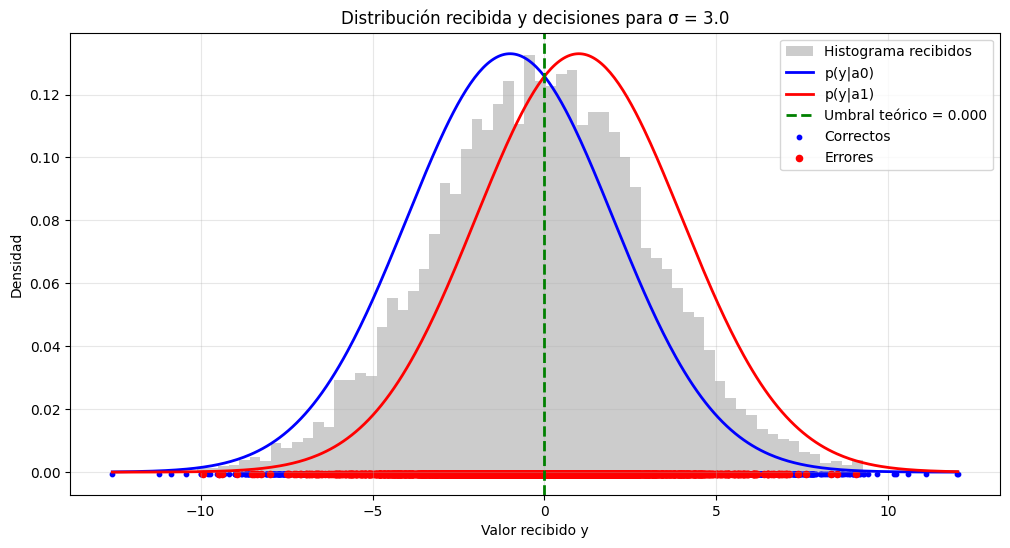

In [42]:
# Celda 7: Visualización para varios valores de σ

sigma_list = [0.2, 0.5, 1.0, 1.5, 2.0, 3.0]

for sig in sigma_list:

    # ============================================================
    # 1) Generar ruido y señal recibida para este sigma
    # ============================================================
    noise = torch.normal(mean=0.0, std=sig, size=(N,))
    received_current = transmitted_signal + noise

    # ============================================================
    # 2) Calcular probabilidades
    # ============================================================
    Pe_theo = calculate_error_probability(sig, a0, a1)
    Pe_emp  = estimate_error_empirical(symbols, received_current, threshold_theoretical)

    print(f"\n====================== σ = {sig} ======================")
    print(f"Pe teórica:   {Pe_theo:.6f} ({Pe_theo*100:.3f}%)")
    print(f"Pe empírica:  {Pe_emp:.6f} ({Pe_emp*100:.3f}%)")
    print(f"Número de errores: {int(Pe_emp * N)} de {N}")

    # ============================================================
    # 3) Gráfica explicativa
    # ============================================================

    plt.figure(figsize=(12,6))

    # Histograma
    plt.hist(received_current.numpy(), bins=80, density=True, alpha=0.4,
             color='gray', label='Histograma recibidos')

    # PDFs teóricas
    y_range = np.linspace(received_current.min(), received_current.max(), 400)
    pdf0 = stats.norm.pdf(y_range, loc=a0, scale=sig)
    pdf1 = stats.norm.pdf(y_range, loc=a1, scale=sig)

    plt.plot(y_range, pdf0, 'b-', linewidth=2, label='p(y|a0)')
    plt.plot(y_range, pdf1, 'r-', linewidth=2, label='p(y|a1)')

    # Umbral teórico
    plt.axvline(threshold_theoretical, color='green', linestyle='--',
                linewidth=2, label=f'Umbral teórico = {threshold_theoretical:.3f}')

    # Decisiones
    decision = (received_current >= threshold_theoretical).float()

    idx_errors   = torch.where(decision != symbols)[0]
    idx_corrects = torch.where(decision == symbols)[0]

    # puntos correctos azul
    plt.scatter(received_current[idx_corrects].numpy(),
                np.full(len(idx_corrects), -0.0005),
                color='blue', s=10, label='Correctos')

    # puntos incorrectos rojo
    plt.scatter(received_current[idx_errors].numpy(),
                np.full(len(idx_errors), -0.0005),
                color='red', s=20, label='Errores')

    plt.title(f"Distribución recibida y decisiones para σ = {sig}")
    plt.xlabel("Valor recibido y")
    plt.ylabel("Densidad")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


#Celda 8: Variar el SNR (o σ) en un rango amplio y observar comportamiento

##  **8. Variación de SNR/σ**
Barremos \\(\sigma\\) en un rango amplio:

$$
\sigma \in [0.1, 10]
$$

Y comparamos:

- **Curva teórica Pe(σ)**
- **Curva empírica Pe(σ)**

También se usa la relación:

$$
\text{SNR(dB)} = 10 \log_{10}\left( \frac{1}{2\sigma^2} \right)
$$

Resultados:

- **SNR alto → Pe casi cero**
- **SNR bajo → Pe se acerca a 0.5**

-**A mayor ruido (σ grande) → mayor probabilidad de error.**  
-**A menor ruido (σ pequeño) → mejor desempeño del sistema.**  


Simulando para diferentes valores de SNR...

σ=0.100, SNR=16.99dB: Pe_teórica=0.000000, Pe_empírica=0.000000
σ=0.336, SNR=6.46dB: Pe_teórica=0.001459, Pe_empírica=0.001477
σ=1.129, SNR=-4.06dB: Pe_teórica=0.187845, Pe_empírica=0.197242
σ=3.793, SNR=-14.59dB: Pe_teórica=0.396019, Pe_empírica=0.393376

✓ Simulación completada


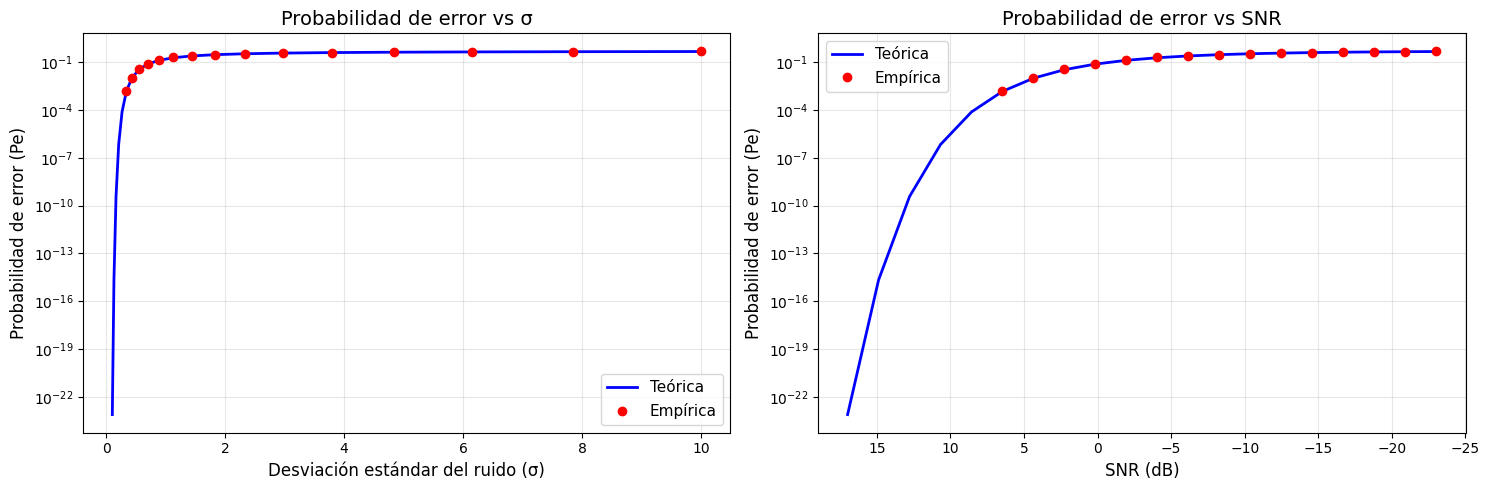


RESUMEN DE RESULTADOS
       σ   SNR (dB)      Pe Teórica     Pe Empírica    Errores
----------------------------------------------------------------------
   0.100      16.99        0.000000        0.000000          0
   0.336       6.46        0.001459        0.001477         12
   1.129      -4.06        0.187845        0.197242       1602
   3.793     -14.59        0.396019        0.393376       3195
  10.000     -23.01        0.460172        0.463433       3764


In [28]:
# Rango de valores de σ (desviación estándar del ruido)
sigma_values = np.logspace(-1, 1, 20)  # Desde 0.1 hasta 10
SNR_dB_values = 10 * np.log10(1 / (2 * sigma_values**2))

Pe_theoretical_list = []
Pe_empirical_list = []

print("Simulando para diferentes valores de SNR...\n")

for i, sig in enumerate(sigma_values):
    # Generar nueva señal para cada σ
    noise_current = torch.normal(mean=0.0, std=sig, size=(N,))
    received_current = transmitted_signal + noise_current

    # Calcular probabilidad de error teórica
    Pe_theo = calculate_error_probability(sig, a0, a1, threshold_theoretical)
    Pe_theoretical_list.append(Pe_theo)

    # Calcular probabilidad de error empírica
    Pe_emp = estimate_error_empirical(symbols, received_current, threshold_theoretical)
    Pe_empirical_list.append(Pe_emp)

    if i % 5 == 0:  # Imprimir cada 5 valores
        print(f"σ={sig:.3f}, SNR={SNR_dB_values[i]:.2f}dB: Pe_teórica={Pe_theo:.6f}, Pe_empírica={Pe_emp:.6f}")

print("\n✓ Simulación completada")

# Visualización de resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Pe vs σ
ax1.semilogy(sigma_values, Pe_theoretical_list, 'b-', linewidth=2, label='Teórica')
ax1.semilogy(sigma_values, Pe_empirical_list, 'ro', markersize=6, label='Empírica')
ax1.set_xlabel('Desviación estándar del ruido (σ)', fontsize=12)
ax1.set_ylabel('Probabilidad de error (Pe)', fontsize=12)
ax1.set_title('Probabilidad de error vs σ', fontsize=14)
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=11)

# Gráfico 2: Pe vs SNR
ax2.semilogy(SNR_dB_values, Pe_theoretical_list, 'b-', linewidth=2, label='Teórica')
ax2.semilogy(SNR_dB_values, Pe_empirical_list, 'ro', markersize=6, label='Empírica')
ax2.set_xlabel('SNR (dB)', fontsize=12)
ax2.set_ylabel('Probabilidad de error (Pe)', fontsize=12)
ax2.set_title('Probabilidad de error vs SNR', fontsize=14)
ax2.grid(True, alpha=0.3, which='both')
ax2.legend(fontsize=11)
ax2.invert_xaxis()  # SNR alto → error bajo

plt.tight_layout()
plt.show()

# Tabla resumen
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS")
print("="*70)
print(f"{'σ':>8} {'SNR (dB)':>10} {'Pe Teórica':>15} {'Pe Empírica':>15} {'Errores':>10}")
print("-"*70)
for i in [0, len(sigma_values)//4, len(sigma_values)//2, 3*len(sigma_values)//4, -1]:
    sig = sigma_values[i]
    snr = SNR_dB_values[i]
    pe_t = Pe_theoretical_list[i]
    pe_e = Pe_empirical_list[i]
    errors = int(pe_e * N)
    print(f"{sig:8.3f} {snr:10.2f} {pe_t:15.6f} {pe_e:15.6f} {errors:10d}")
print("="*70)